In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 1. 기술 통계량
# 2. 결측지 확인 -> 인덱스 3,339 삭제
# 3. 분포확인(평균,중앙값) -> species 분포 확인
# 4. 상관관계 -> 시각화 , corr()
# 5. 결과해석

In [2]:
pdf= sns.load_dataset("penguins")
pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [ ]:
#결측지 2개 삭제

pdf.drop(index=[3, 339], inplace=True)  # index 3,339번째 삭제
pdf.reset_index(drop=True, inplace=True)# 인덱싱 설정 초기화

pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    str    
 1   island             342 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.8 KB


In [ ]:
# sex 결측지 9개 삭제

pdf.dropna(subset=["sex"], inplace=True) # sex 컬럼에서 null 값만 삭제
pdf.reset_index(drop=True, inplace=True) # 인덱싱 초기화 설정

pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.3 KB


In [5]:
pdf["species"].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [9]:
print(pdf.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen            36.7           19.3              193.0   
4  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3       3450.0  Female  
4       3650.0    Male  


In [ ]:
#상관계수 확인

corr= pdf.corr(numeric_only=True)

print(corr)

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  


<Axes: xlabel='species', ylabel='Count'>

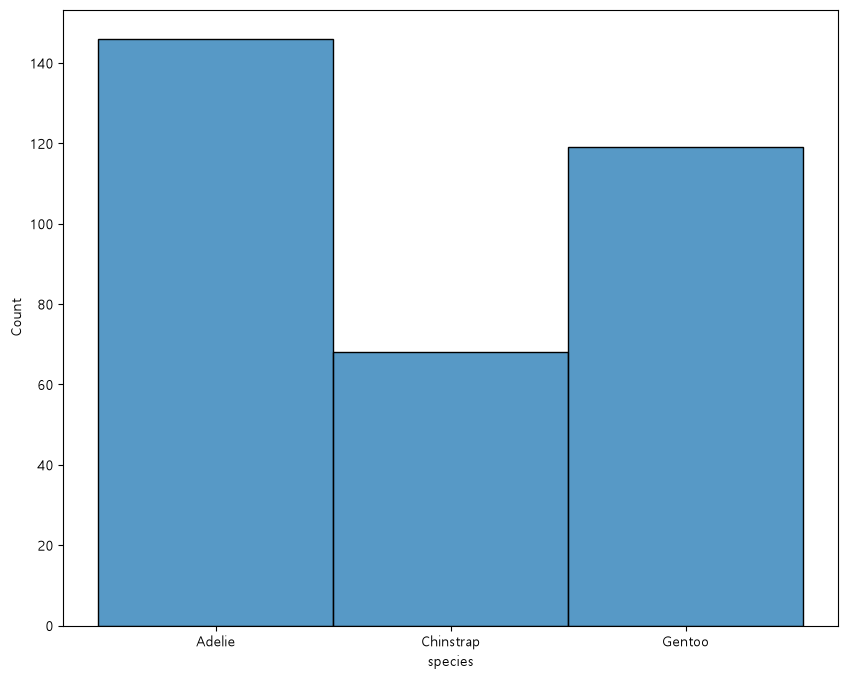

In [11]:
fig=plt.figure(figsize=(10,8))

axes1 = fig.add_subplot(1,1,1)

sns.histplot(
    data= pdf,
    x= "species",
    bins=10,
    ax=axes1
)

<Axes: xlabel='bill_length_mm', ylabel='Count'>

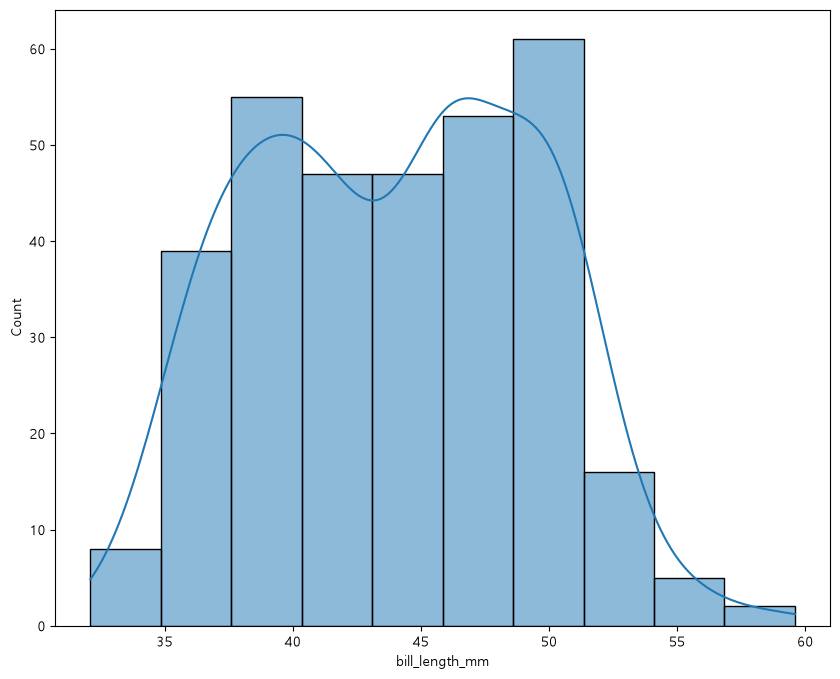

In [12]:
fig=plt.figure(figsize=(10,8))

axes1 = fig.add_subplot(1,1,1)

sns.histplot(
    data= pdf,
    x= "bill_length_mm",
    bins=10,
    kde=True,
    ax=axes1
)



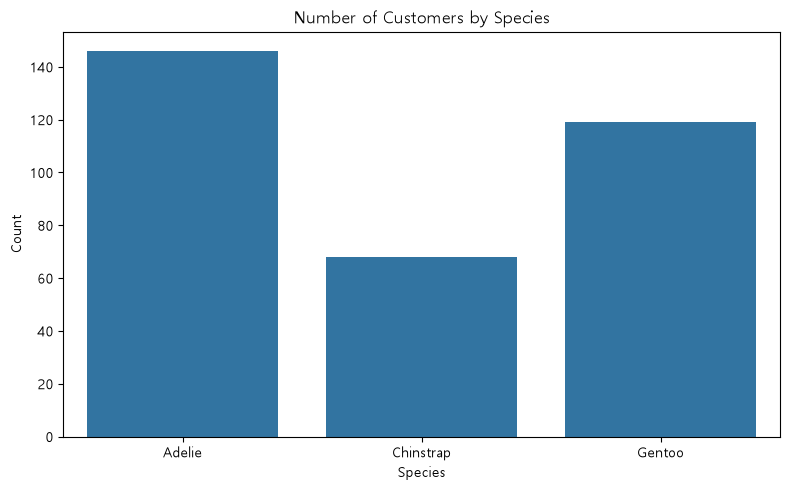

In [ ]:
# Figure 생성
fig = plt.figure(figsize=(8, 5))

# Figure 안에 1개의 Axes 생성
axes1 = fig.add_subplot(1, 1, 1)

sns.countplot(
    data=pdf,
    x="species",
    ax=axes1
)

axes1.set_title("Number of Customers by Species")
axes1.set_xlabel("Species")
axes1.set_ylabel("Count")

fig.tight_layout()

plt.show()

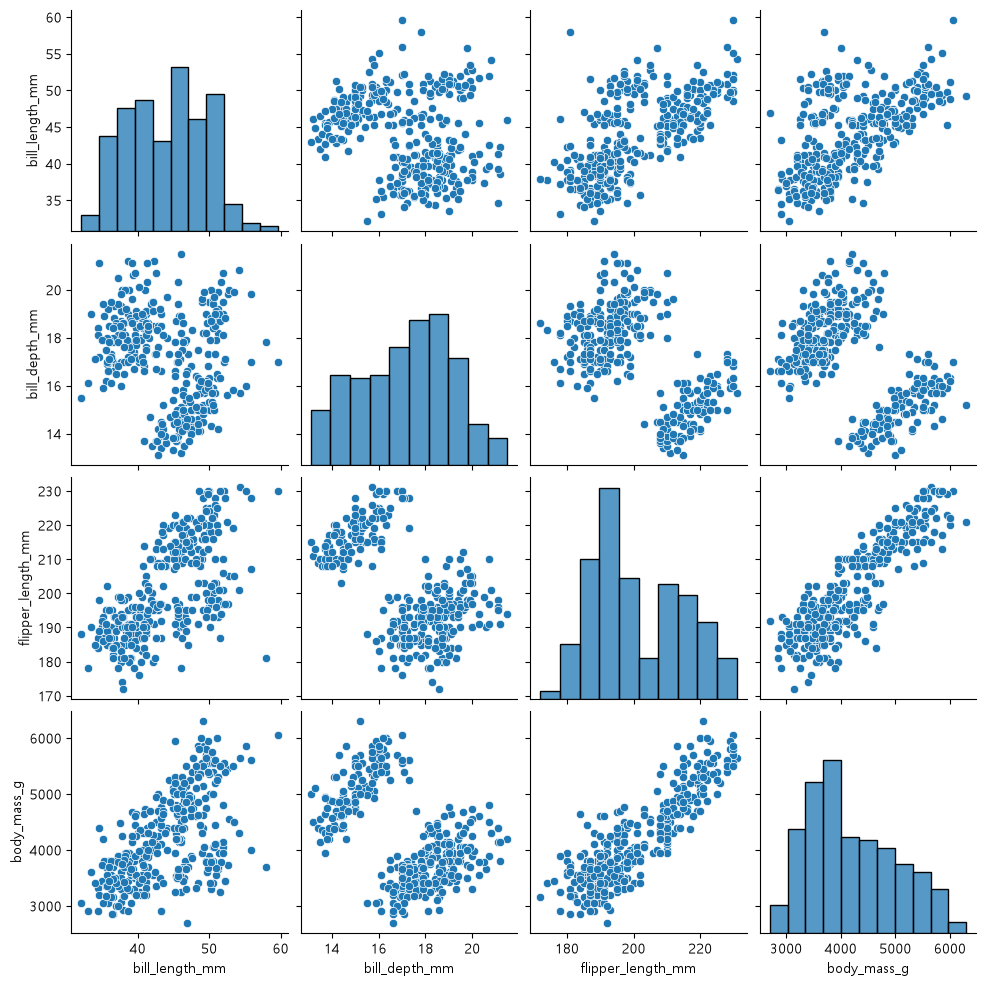

In [ ]:
#pairplot: 여러 숫자형 변수 사이의 관계를 한꺼번에 탐색하는 그래프
sns.pairplot(
    data=pdf
)

plt.show()